In [1]:
import pandas as pd

import sys
sys.path.append("../")
import FragShapley
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, BRICS
from rdkit.Chem.Scaffolds import MurckoScaffold

/home/jannik/Documents/studies/phd/03_work/20_FragShapley/FragShapley/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mol_from_smiles(smiles):
    return Chem.MolFromSmiles(smiles)

def compute_properties(smiles):
    mol = mol_from_smiles(smiles)

    if mol is None:
        return pd.Series({
            "mol_wt": np.nan,
            "logp": np.nan,
            "tpsa": np.nan,
            "hbd": np.nan,
            "hba": np.nan,
            "rot_bonds": np.nan,
            "n_rings": np.nan,
            "heavy_atoms": np.nan,
            "fsp3": np.nan,
        })

    return pd.Series({
        "mol_wt": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "tpsa": Descriptors.TPSA(mol),
        "hbd": Descriptors.NumHDonors(mol),
        "hba": Descriptors.NumHAcceptors(mol),
        "rot_bonds": Descriptors.NumRotatableBonds(mol),
        "n_rings": rdMolDescriptors.CalcNumRings(mol),
        "heavy_atoms": mol.GetNumHeavyAtoms(),
        "fsp3": rdMolDescriptors.CalcFractionCSP3(mol),
    })

In [3]:
def get_bm_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold, canonical=True, isomericSmiles=False)

# Analyze datasets

On target Solubility (logS) there are 269 unique BM scaffolds.
Number of compunds without a BM Scaffold: [314]
On target SARS there are 481 unique BM scaffolds.
Number of compunds without a BM Scaffold: []
On target Mutagenicity there are 1523 unique BM scaffolds.
Number of compunds without a BM Scaffold: [1125]


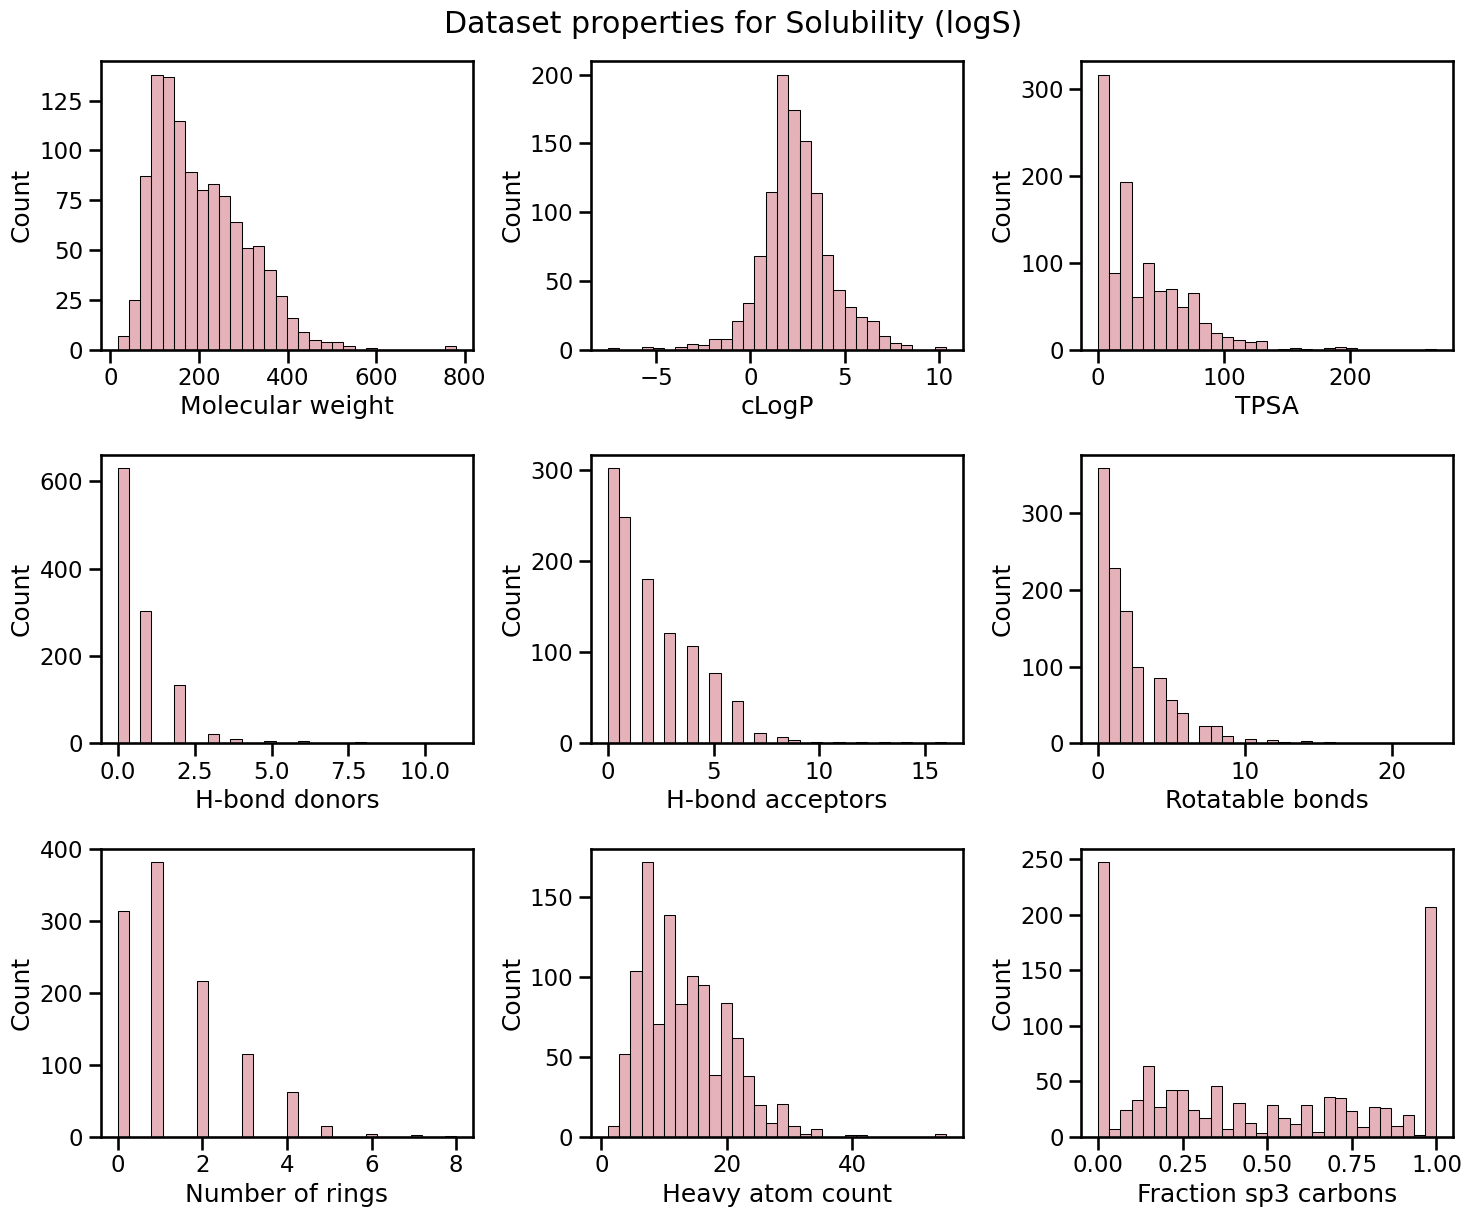

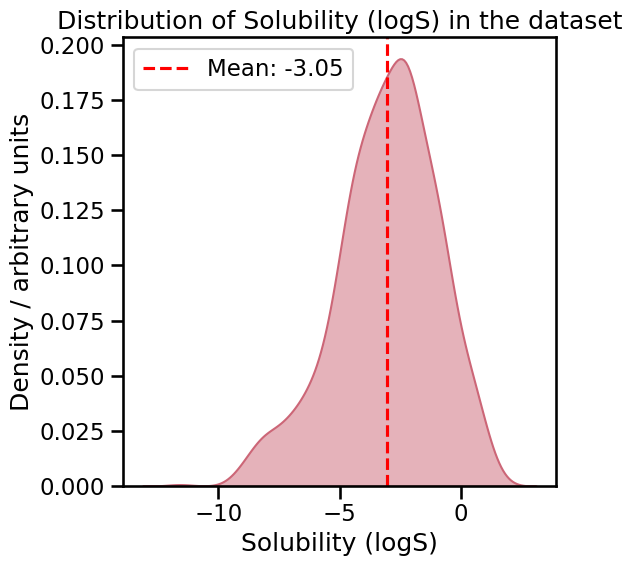

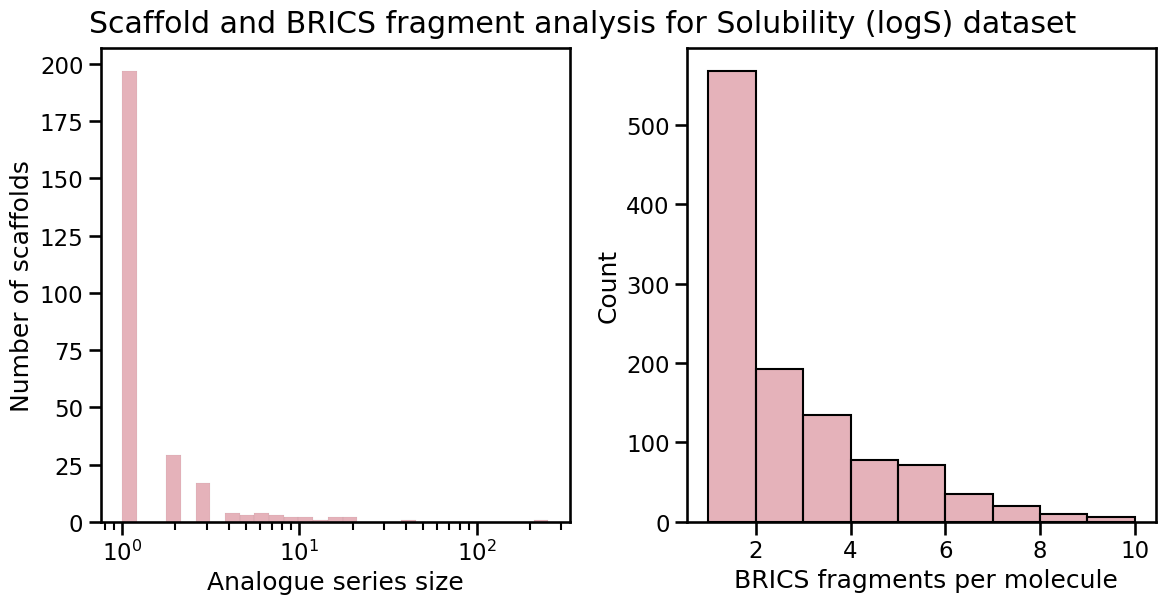

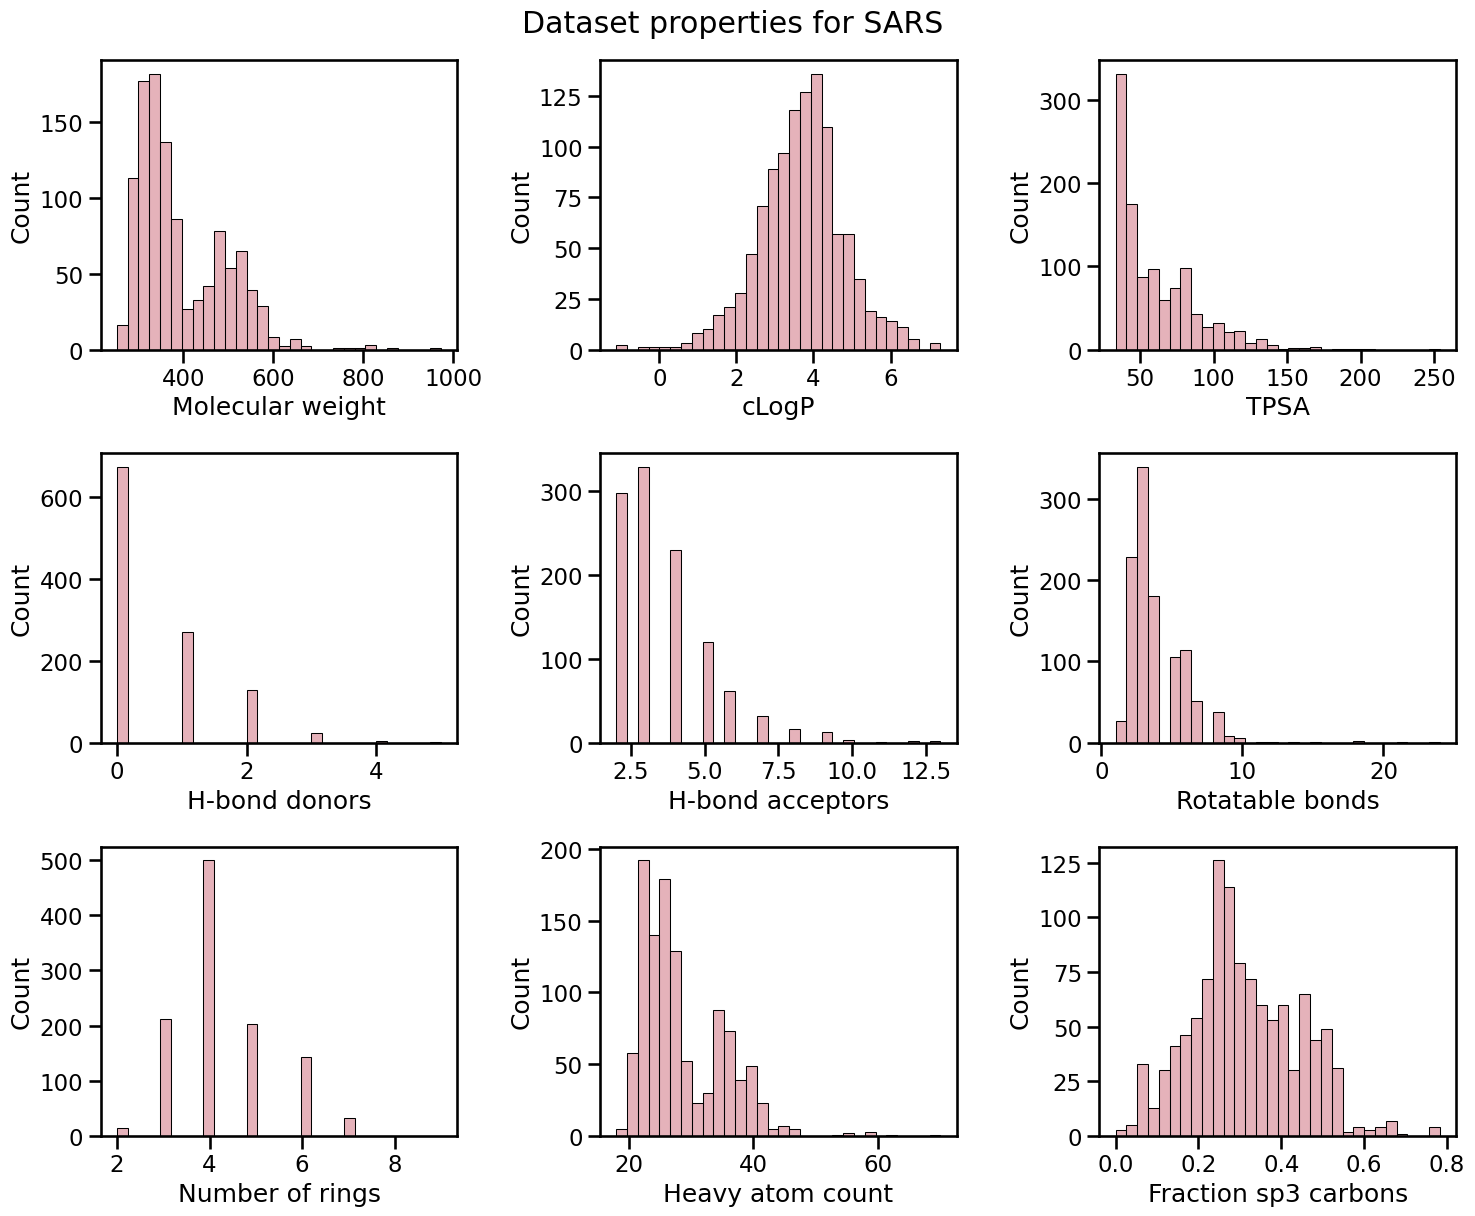

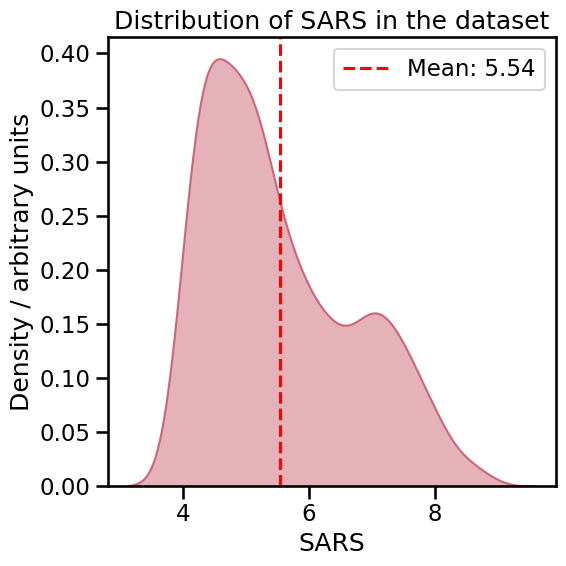

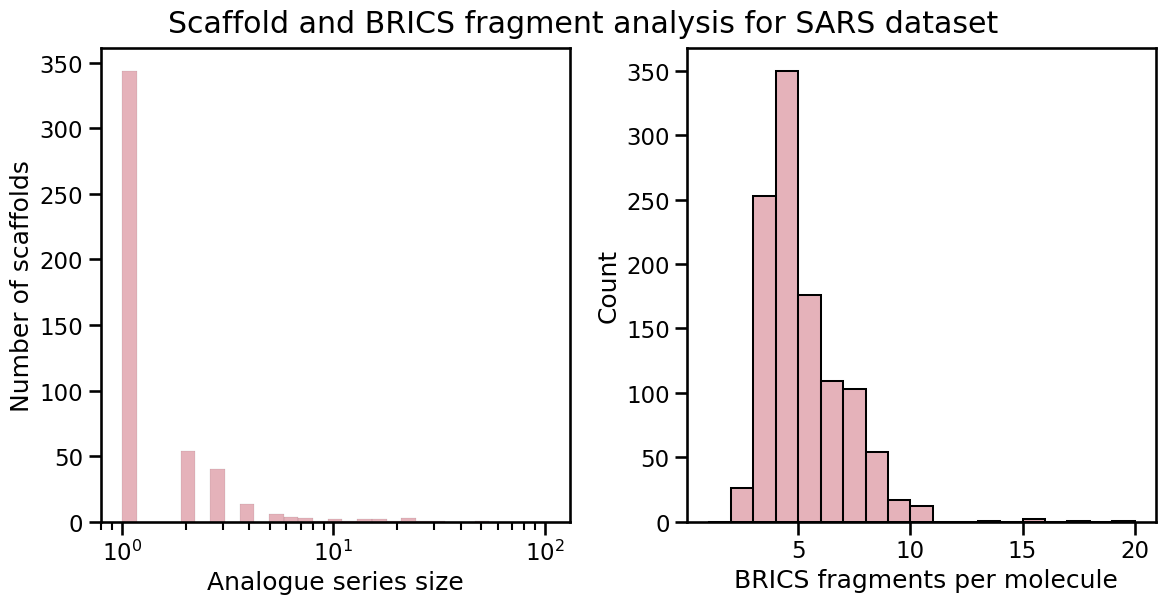

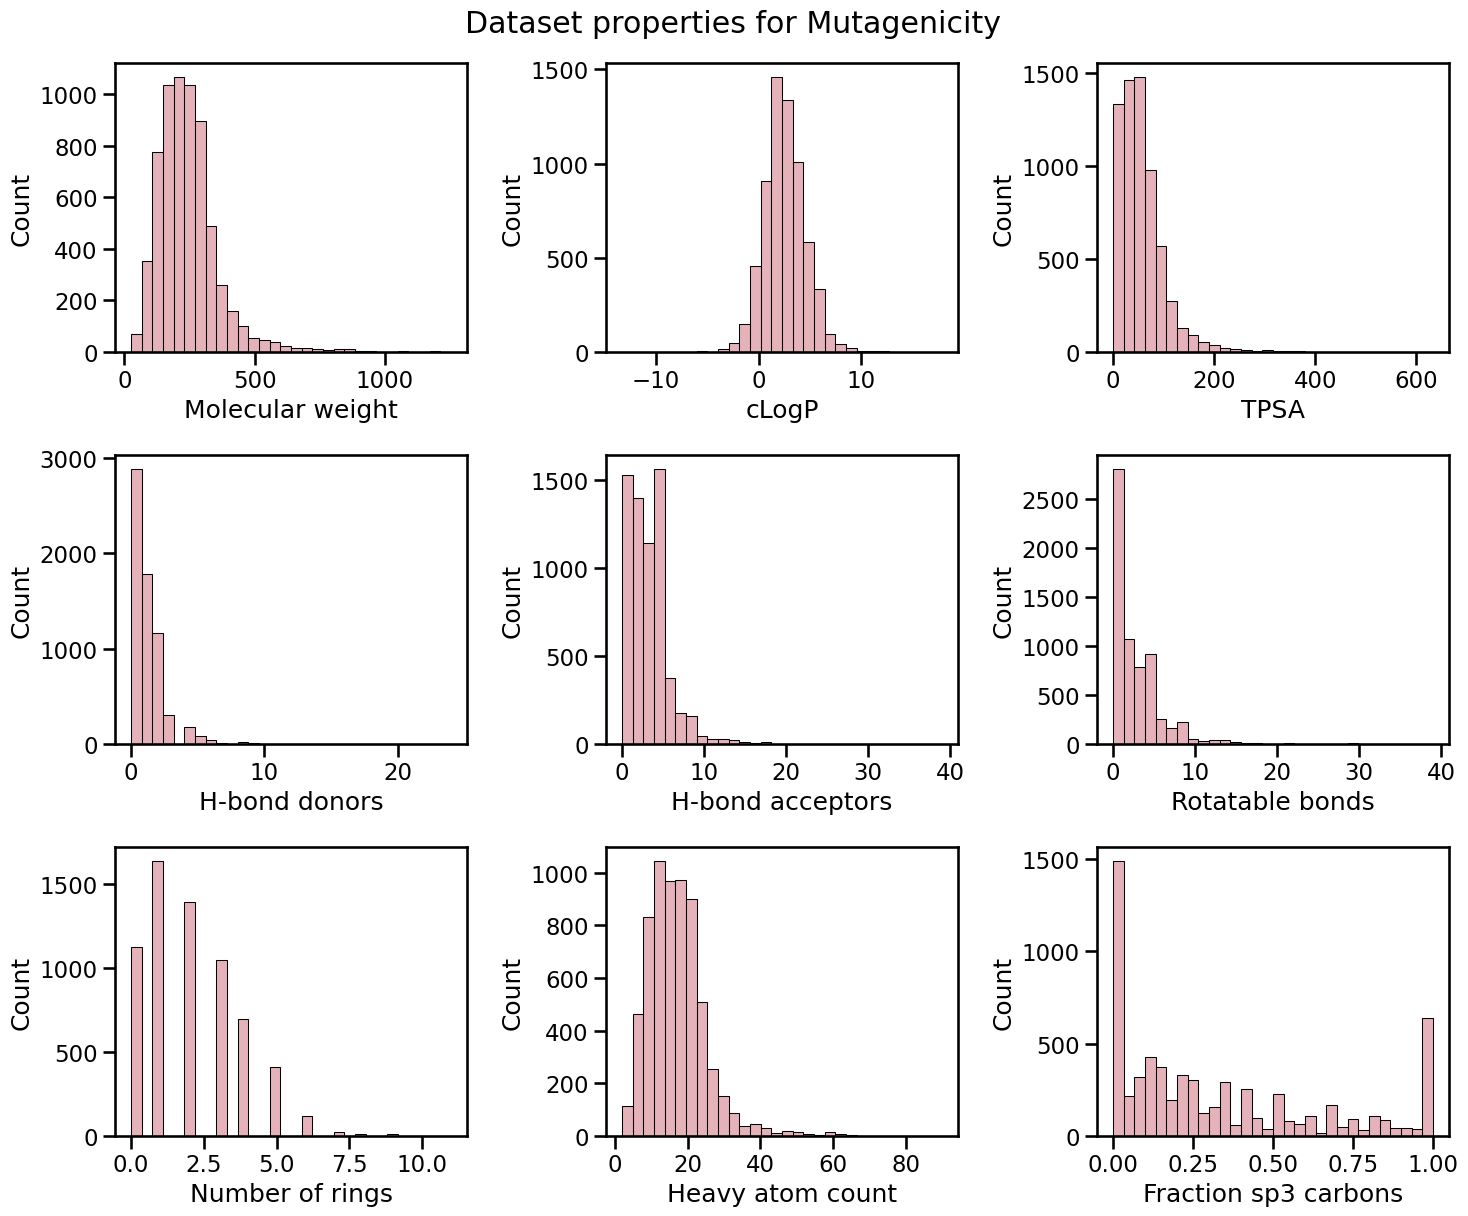

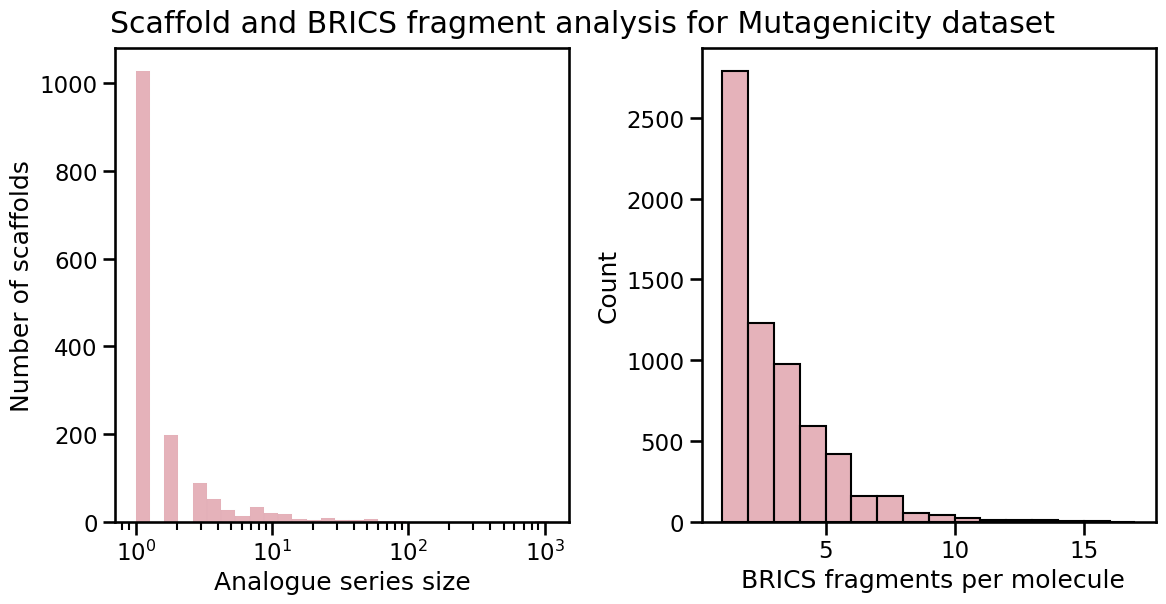

In [12]:
paths = ['../0_datasets/regression/esol_delaney.csv', '../0_datasets/regression/SARS.csv', '../0_datasets/classification/Hansen.csv']
smiles_columns = ['nonstereo_aromatic_smiles', 'canonical_smiles', 'nonstereo_aromatic_smiles']
target_columns = ['solubility', 'pIC50', 'mutagenicity']
target_names = ["Solubility (logS)", "SARS", 'Mutagenicity']
results = []

for path, smiles_column, target_column, target_name in zip(paths, smiles_columns, target_columns, target_names):
    df = pd.read_csv(path)


    # calculate properties
    property_df = df[smiles_column].apply(compute_properties)
    df = pd.concat([df, property_df], axis=1)

    # scaffolds and BRICS fragments
    df["bm_scaffold"] = df[smiles_column].apply(get_bm_scaffold)
    df["brics_fragments"] = df[smiles_column].apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=False))
    df["n_brics_fragments"] = df["brics_fragments"].apply(len)

    # Plotting now
    properties = [
        "mol_wt",
        "logp",
        "tpsa",
        "hbd",
        "hba",
        "rot_bonds",
        "n_rings",
        "heavy_atoms",
        "fsp3",
    ]

    property_labels = {
        "mol_wt": "Molecular weight",
        "logp": "cLogP",
        "tpsa": "TPSA",
        "hbd": "H-bond donors",
        "hba": "H-bond acceptors",
        "rot_bonds": "Rotatable bonds",
        "n_rings": "Number of rings",
        "heavy_atoms": "Heavy atom count",
        "fsp3": "Fraction sp3 carbons",
    }



    fig, axs = plt.subplots(3, 3, figsize=(15, 12))
    axs = axs.flatten()

    for ax, prop in zip(axs, properties):
        sns.histplot(
            df[prop].dropna(),
            bins=30,
            alpha=0.5,
            ax=ax
        )

        ax.set_xlabel(property_labels[prop])

    fig.tight_layout()
    fig.suptitle(f"Dataset properties for {target_name}", y=1.02)
    fig.savefig(os.path.join(fig_folder, f"final_figures/S_{target_column}_dataset_properties.pdf"))

    if target_name.lower() != 'mutagenicity':
        fig, axs = plt.subplots(1, 1, figsize=(6, 6))

        sns.kdeplot(
            df[target_column].dropna(),
            fill=True,
            alpha=0.5,
            ax=axs)

        # mark mean value
        mean_val = df[target_column].mean()
        axs.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axs.legend()
        axs.set_xlabel(target_name)
        axs.set_ylabel("Density / arbitrary units")
        axs.set_title(f"Distribution of {target_name} in the dataset")
        fig.tight_layout()
        fig.savefig(os.path.join(fig_folder, f"final_figures/S_{target_column}_dataset_kde.pdf"))

    # now scaffolds
    scaffold_counts = (
        df.groupby(["bm_scaffold"])
        .size()
        .reset_index(name="series_size")
    )
    print(f'On target {target_name} there are {scaffold_counts.shape[0]} unique BM scaffolds.')
    print(f'Number of compunds without a BM Scaffold: {scaffold_counts.query("bm_scaffold == ''").series_size.values}')

    # remove compounds without scaffold
    scaffold_counts = scaffold_counts.query("bm_scaffold != ''")
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    sns.histplot(
            scaffold_counts["series_size"],
            bins=np.logspace(0, np.log10(scaffold_counts["series_size"].max()), 30),
            alpha=0.5,
            ax=axs[0]
    )
    axs[0].set_xscale("log")
    axs[0].set_xlabel("Analogue series size")
    axs[0].set_ylabel("Number of scaffolds")

    sns.histplot(
            df["n_brics_fragments"],
            bins=range(1, int(df["n_brics_fragments"].max()) + 2),
            alpha=0.5,
            ax=axs[1],
    )
    axs[1].set_xlabel(" BRICS fragments per molecule")
    axs[1].set_ylabel("Count")

    fig.tight_layout()
    fig.suptitle(f"Scaffold and BRICS fragment analysis for {target_name} dataset", y=1.02)
    fig.savefig(os.path.join(fig_folder, f"final_figures/S_{target_column}_dataset_scaffold_brics.pdf"))

    # some basic analysis
    dataset_size = df.shape[0]
    n_scaffolds = scaffold_counts.shape[0]
    avg_series_size = scaffold_counts["series_size"].mean()
    brics_fragments = df.brics_fragments.explode().to_list()
    n_brics_fragments = len(brics_fragments)
    n_unique_brics_fragments = len(set(brics_fragments))
    brics_fragments_per_molecule = df["n_brics_fragments"].mean()

    res = {'dataset': target_name,
        'dataset_size': dataset_size,
        'n_scaffolds': n_scaffolds,
        'avg_series_size': avg_series_size,
        'n_brics_fragments': n_brics_fragments,
        'n_unique_brics_fragments': n_unique_brics_fragments,
        'brics_fragments_per_molecule': brics_fragments_per_molecule,
        'cpds_single_brics_fragment': len(df.query('n_brics_fragments == 1'))
        }
    results.append(res)

overview_df = pd.DataFrame(results)

In [13]:
df

,nonstereo_aromatic_smiles,mutagenicity,mol_wt,logp,tpsa,hbd,hba,rot_bonds,n_rings,heavy_atoms,fsp3,bm_scaffold,brics_fragments,n_brics_fragments
0,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0,646.614,6.34940,134.00,2.0,6.0,0.0,11.0,50.0,0.000000,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,[O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4ccc...,1
1,CC(=O)OC1(C(C)=O)CCC2C3C=C(Cl)C4=CC(=O)OCC4(C)...,0,406.906,3.94560,69.67,0.0,5.0,2.0,4.0,28.0,0.681818,O=C1C=C2C=CC3C4CCCC4CCC3C2CO1,"[*C(C)=O, *O*, *C1(*)CCC2C3C=C(Cl)C4=CC(=O)OCC...",4
2,Nc1nc(N)nc(N)n1,0,126.123,-1.38180,116.73,3.0,6.0,0.0,1.0,9.0,0.000000,c1ncncn1,[Nc1nc(N)nc(N)n1],1
3,Cc1ccc(N=Nc2c(O)ccc3ccccc23)c([N+](=O)[O-])c1,1,307.309,5.17742,88.09,1.0,5.0,3.0,3.0,23.0,0.058824,c1ccc(N=Nc2cccc3ccccc23)cc1,[Cc1ccc(N=Nc2c(O)ccc3ccccc23)c([N+](=O)[O-])c1],1
4,CC(C)CC(=O)Nc1snc2ccccc12,0,234.324,3.28090,41.99,1.0,3.0,3.0,2.0,16.0,0.333333,c1ccc2nscc2c1,"[*C(=O)CC(C)C, *N*, *c1snc2ccccc12]",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6487,COC1COC(COCC2COC(OC)C(OS(=O)(=O)O)C2OS(=O)(=O)...,0,658.609,-3.21230,300.55,4.0,17.0,14.0,2.0,39.0,1.000000,C1CCC(COCC2CCCOC2)OC1,"[*OC, *C1COC(*)C(*)C1*, *C*, *O*, *C*, *C1COC(...",11
6488,O=Nn1cc(CC(O)C(=O)O)c2ccccc21,1,234.211,1.15880,91.89,2.0,5.0,4.0,2.0,17.0,0.181818,c1ccc2[nH]ccc2c1,"[*c1cn(N=O)c2ccccc12, *CC(O)C(=O)O]",2
6489,COC(=O)Nc1nc2ccccc2[nH]1,1,191.190,1.74120,67.01,2.0,3.0,1.0,2.0,14.0,0.111111,c1ccc2[nH]cnc2c1,"[*OC, *C(*)=O, *N*, *c1nc2ccccc2[nH]1]",4
6490,ClCc1cccc2c1-c1cccc3cccc-2c13,1,250.728,5.22600,0.00,0.0,0.0,1.0,4.0,18.0,0.058824,c1ccc2c(c1)-c1cccc3cccc-2c13,"[*CCl, *c1cccc2c1-c1cccc3cccc-2c13]",2


In [15]:
print(overview_df)

             dataset  dataset_size  n_scaffolds  avg_series_size  \
0  Solubility (logS)          1115          268         2.988806   
1               SARS          1105          481         2.297297   
2       Mutagenicity          6492         1522         3.526281   

   n_brics_fragments  n_unique_brics_fragments  brics_fragments_per_molecule  \
0               2510                       999                      2.251121   
1               5250                       704                      4.751131   
2              16278                      5182                      2.507394   

   cpds_single_brics_fragment  
0                         568  
1                           0  
2                        2792  


For the response letter

You can answer very simply:

We thank the reviewer for this suggestion. To better characterize the datasets, we added a new Supporting Information section summarizing molecular property distributions, target value distributions, scaffold statistics, and BRICS fragment statistics for all datasets (Table Sx and Figures Sy–Sz).

That should completely satisfy the reviewer.

Honestly, among all reviewer comments you've shown so far, this is one of the easiest to resolve and your current analysis already goes beyond what was requested.